
##Ciencia de Datos con dataset Lenguajes de Programación

###Objetivo: explorar y visualizar los datos para responder preguntas clave y presentar insights de valor

Pasos a seguir:

    -Seleccionar dataset: Temática "Lenguajes de Programación"

    -Analizar el dataset inicial:
      Identificar valores nulos
      Detectar registros duplicados

    -Realizar el perfilado de datos:
      Analizar estadísticas descriptivas
      Identificar inconsistencias
  
    -Aplicar limpieza de datos:
      Eliminar duplicados
      Imputar valores faltantes
      Normalizar variables categóricas
  
    -Realizar análisis exploratorio (EDA):
      Analizar distribuciones
      Detectar outliers
      Evaluar relaciones entre variables
  
    -Creación de Visualizaciones:
      Crear al menos tres visualizaciones diferentes para representar los datos:
      gráfico de barras o columnas para comparar categorías, gráfico de líneas para mostrar tendencias en el tiempo, mapa
      si los datos incluyen información geográfica
  
  Analizar los resultados obtenidos y resumir algunos aspectos importantes de lo obtenido. Por ejemplo, podrías resaltar tendencias notables, patrones inesperados o comparaciones significativas

In [ ]:
# importo las librerias

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#1 cargo el archivo csv que esta en el drive, dar acceso previamente

df = pd.read_csv('/content/drive/MyDrive/CARACT-LENG-PROG/tareras/tiobe_index_feb_2026.csv')




In [ ]:
#2 Analizar el dataset inicial:
#verificar si hay celdas con valores nulos

df.isnull().sum()

#verifica si hay duplicados

df.duplicated().sum()

np.int64(0)

In [ ]:
#3 Realizar el perfilado de datos:

# muestra info estadísticas descriptivas

df.info()

#muestra valores
df.describe()

# muestra valores columna language para verificar inconsistencias

df['Language'].unique()

#muestra valores columna creator para verificar inconsistencias

df['Creator'].unique()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          28 non-null     int64  
 1   Language      28 non-null     object 
 2   Rating_Pct    28 non-null     float64
 3   Change_Pct    28 non-null     float64
 4   Status        28 non-null     object 
 5   Paradigm      28 non-null     object 
 6   Year_Created  28 non-null     int64  
 7   Creator       28 non-null     object 
 8   Primary_Use   28 non-null     object 
 9   Typing        25 non-null     object 
dtypes: float64(2), int64(2), object(6)
memory usage: 2.3+ KB


array(['Guido van Rossum', 'Dennis Ritchie', 'Bjarne Stroustrup',
       'James Gosling', 'Anders Hejlsberg', 'Brendan Eich', 'Microsoft',
       'R. Ihaka & R. Gentleman', 'Donald Chamberlin', 'Larry Wall',
       'John Backus', 'Rasmus Lerdorf', 'Graydon Hoare',
       'Robert Griesemer', 'Cleve Moler', 'MIT Media Lab', 'Various',
       'JetBrains', 'Apple Inc.', 'Grace Hopper (team)',
       'Alain Colmerauer', 'PUC-Rio team', 'Yukihiro Matsumoto', 'Google',
       'Martin Odersky'], dtype=object)

In [ ]:
#4 Aplicar limpieza de datos:
#eliminar duplicados

df = df.drop_duplicates()

#verifico que no hay duplicados
df.duplicated().sum()

#buscar valores nulos y convertirlo a string N/A, luego de correr el comando ya no quedan valores nulos.

df = df.fillna('N/A')
df.isnull().sum()

#Normalizar variables categóricas

df['Paradigm'] = df['Paradigm'].str.lower() # todos los caracteres en minuscula
df['Paradigm'].unique()

df['Typing'] = df['Typing'].str.lower() # todos los caracteres en minuscula
df['Typing'].unique()

#reemplazo en la columna paradigm el campo 'visual' por 'multi-paradigm' en fila 16

df['Paradigm'] = df['Paradigm'].replace({'visual':'multi-paradigm'})
df['Paradigm'].unique()


array(['multi-paradigm', 'procedural', 'object-oriented', 'functional',
       'declarative', 'imperative', 'logic'], dtype=object)

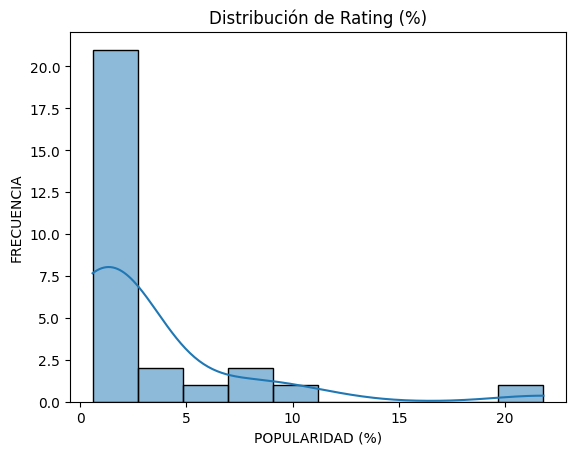

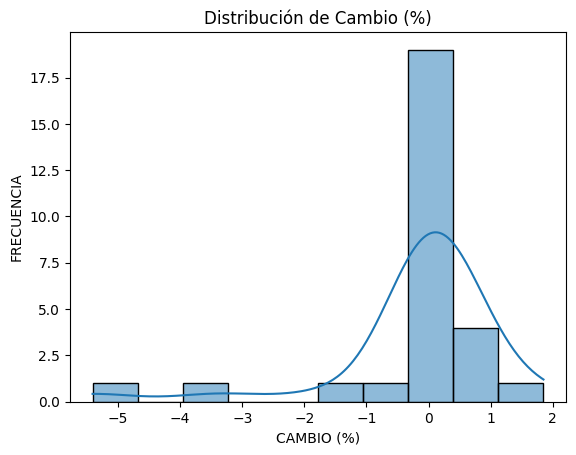

In [ ]:
# Distribuciones
# Distribución de ratings
def plot_rating_distribution(df):
    sns.histplot(df['Rating_Pct'], bins=10, kde=True)
    plt.title("Distribución de Rating (%)")
    plt.xlabel("POPULARIDAD (%)")
    plt.ylabel("FRECUENCIA")
    plt.show()

# Distribución de cambios
def plot_change_distribution(df):
    sns.histplot(df['Change_Pct'], bins=10, kde=True)
    plt.title("Distribución de Cambio (%)")
    plt.xlabel("CAMBIO (%)")
    plt.ylabel("FRECUENCIA")
    plt.show()

plot_rating_distribution(df)
plot_change_distribution(df)

In [ ]:
# Outliers

# Detectar outliers con boxplot
def plot_outliers(df, column):
    sns.boxplot(x=df[column])
    plt.title(f"Outliers en {column}")
    plt.show()

plot_outliers(df, 'Rating_Pct')
plot_outliers(df, 'Change_Pct')

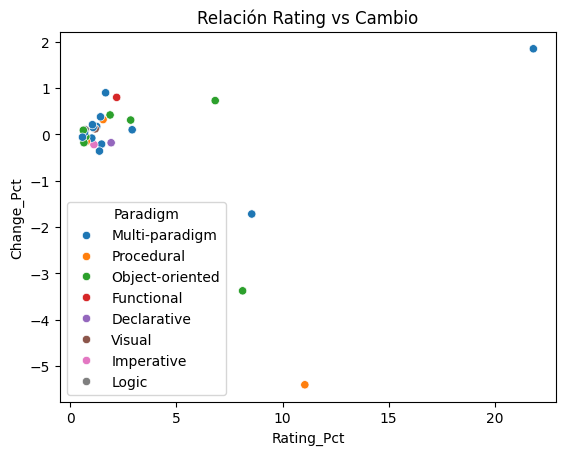

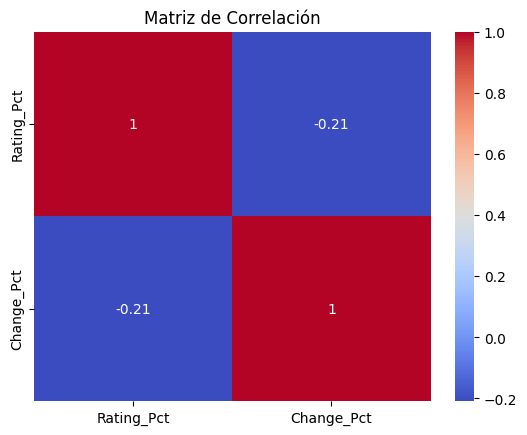

In [ ]:
# Relaciones entre variables

# Relación entre Rating y Change
def plot_relationship(df):
    sns.scatterplot(x='Rating_Pct', y='Change_Pct', data=df, hue='Paradigm')
    plt.title("Relación Rating vs Cambio")
    plt.show()

# Correlación numérica
def correlation_matrix(df):
    corr = df[['Rating_Pct','Change_Pct']].corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm')
    plt.title("Matriz de Correlación")
    plt.show()

plot_relationship(df)
correlation_matrix(df)

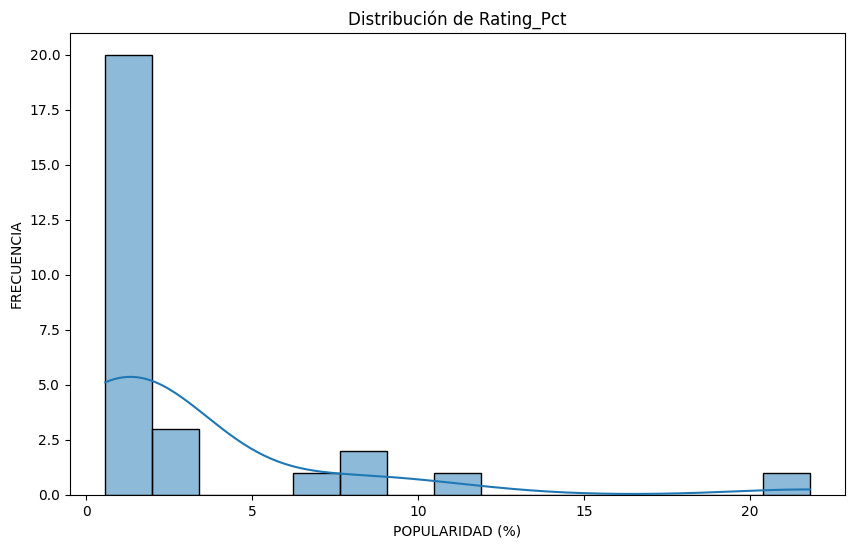

In [ ]:
#5 Realizar análisis exploratorio (EDA):

#EDA (Análisis Exploratorio de Datos): distribuciones, outliers y relaciones entre variables

# Distribución de Rating_Pct
plt.figure(figsize=(10,6))
sns.histplot(df['Rating_Pct'], bins=15, kde=True)
plt.title("Distribución de Rating_Pct")
plt.xlabel("POPULARIDAD (%)")
plt.ylabel("FRECUENCIA")
plt.show()

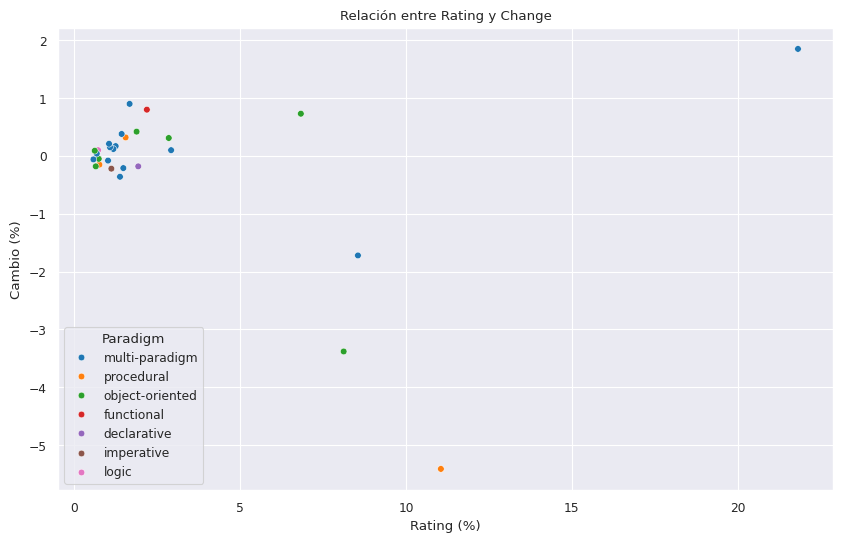

In [ ]:
# Scatter Plot Rating vs Change
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="Rating_Pct", y="Change_Pct", hue="Paradigm")
plt.title("Relación entre Rating y Change")
plt.xlabel("Rating (%)")
plt.ylabel("Cambio (%)")
plt.show()

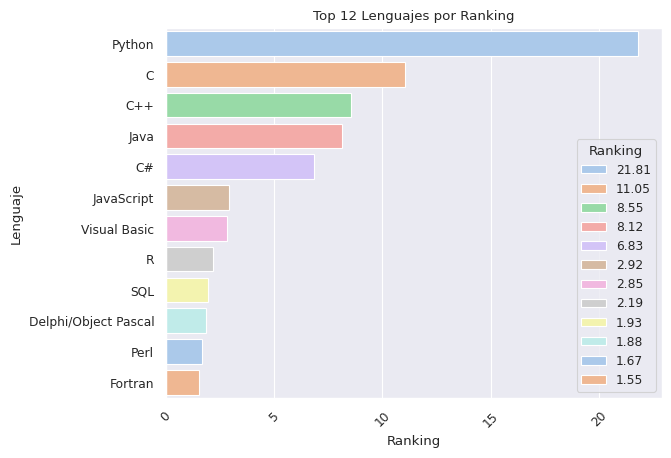

In [ ]:
#6 Creación de Visualizaciones:

def barplot_ratings(df):
    top12 = df.nlargest(12, 'Rating_Pct')
    sns.barplot(x='Rating_Pct', y='Language', data=top12, palette='pastel', hue='Rating_Pct', hue_order=top12['Rating_Pct'])
    sns.set_context("paper")
    plt.xticks(rotation=45)
    plt.xlabel("Ranking")
    plt.ylabel("Lenguaje")
    plt.legend(title="Ranking")
    plt.title("Top 12 Lenguajes por Ranking")
    plt.show()

barplot_ratings(df)

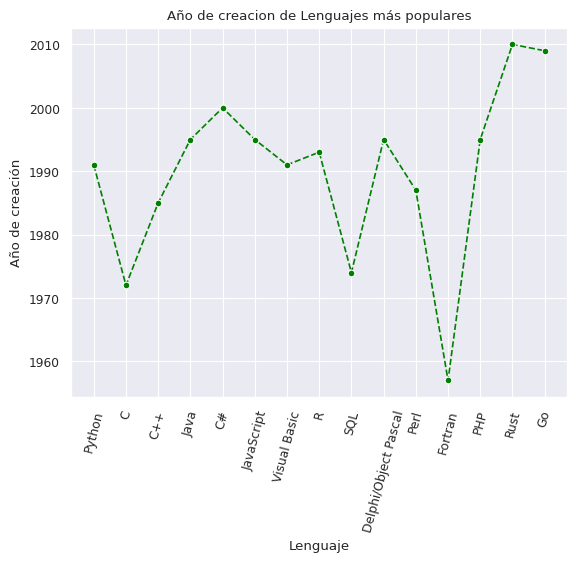

In [ ]:
def lineplot_change(df):
    top15 = df.nlargest(15, 'Rating_Pct')
    sns.lineplot(x='Language', y='Year_Created', data=top15, marker='o', linestyle='--', color='green')
    plt.xlabel("Lenguaje")
    plt.ylabel("Año de creación")
    plt.xticks(rotation=75)
    plt.title("Año de creacion de Lenguajes más populares")
    plt.show()

lineplot_change(df)

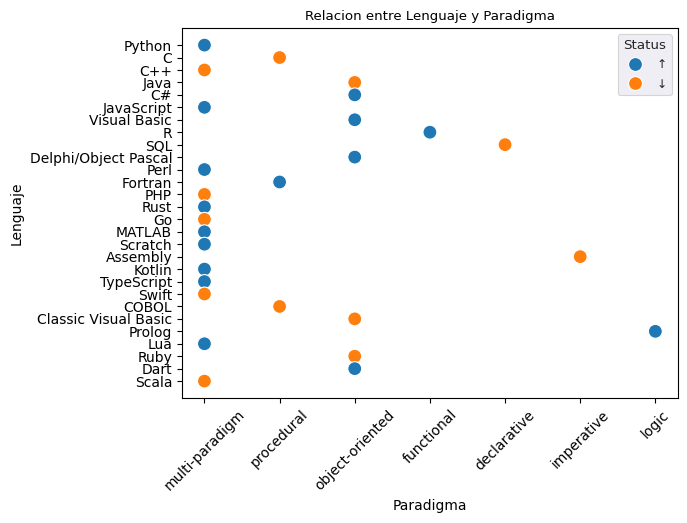

In [ ]:
def scatterplot_relation(df):
    sns.scatterplot(x='Paradigm', y='Language', data=df, hue='Status', s=100)
    sns.set_style("darkgrid")
    sns.set_context("paper")
    plt.xticks(rotation=45)
    plt.xlabel("Paradigma")
    plt.ylabel("Lenguaje")
    plt.legend(title="Status")
    plt.title("Relacion entre Lenguaje y Paradigma")
    plt.show()

scatterplot_relation(df)

In [ ]:
df

,Rank,Language,Rating_Pct,Change_Pct,Status,Paradigm,Year_Created,Creator,Primary_Use,Typing
0,1,Python,21.81,1.85,↑,multi-paradigm,1991,Guido van Rossum,"AI/ML, Data Science, Web",dynamic
1,2,C,11.05,-5.41,↓,procedural,1972,Dennis Ritchie,"Systems, Embedded, OS",static
2,3,C++,8.55,-1.72,↓,multi-paradigm,1985,Bjarne Stroustrup,"Systems, Games, HPC",static
3,4,Java,8.12,-3.38,↓,object-oriented,1995,James Gosling,"Enterprise, Android, Web",static
4,5,C#,6.83,0.73,↑,object-oriented,2000,Anders Hejlsberg,"Enterprise, Games, Web",static
5,6,JavaScript,2.92,0.10,↑,multi-paradigm,1995,Brendan Eich,"Web, Full-stack, Mobile",dynamic
6,7,Visual Basic,2.85,0.31,↑,object-oriented,1991,Microsoft,"Enterprise, Desktop",static
7,8,R,2.19,0.80,↑,functional,1993,R. Ihaka & R. Gentleman,"Statistics, Data Science",dynamic
8,9,SQL,1.93,-0.18,↓,declarative,1974,Donald Chamberlin,"Databases, Analytics",n/a
9,10,Delphi/Object Pascal,1.88,0.42,↑,object-oriented,1995,Anders Hejlsberg,"Desktop, Enterprise",static
